In [1]:
# from numba import cuda
import paicos as pa
import numpy as np
import cupy as cp
import turbocluster as tc
from numba import cuda
import math
import nvtx

# A snapshot object
# snap = pa.Snapshot(pa.data_dir, 247)
snap = pa.Snapshot('/lustre/astro/berlok/zoom-simulations-new-ics/halo_0003/adiabatic-mhd/zoom4_ics_v1/output', 247)
# snap = pa.Snapshot('/lustre/astro/berlok/zoom-simulations-new-ics/halo_0003/tng/zoom12_ics_v1/output', 247)
center = snap.Cat.Group['GroupPos'][0]
widths = np.array([1e3, 1e3, 1e3], dtype=float)

# m_filter = 1000*snap.mass
# filter_length = (np.cbrt(3*m_filter/(4*np.pi*snap['0_Density']))).arepo
filter_length = 0.5*snap['0_Diameters']

# cp.cuda.Device(1).use()

Attempting to get derived variable: 0_Diameters...
	So we need the variable: 0_Volume...	[DONE]



In [2]:
@cuda.jit(device=True, inline=True)
def check_distance(ip_tile_x, ip_tile_y, ip_tile_z,
                   tile_x, tile_y, tile_z,
                   delta_x, delta_y, delta_z,
                   tile_widths, filter_length):

    overlap = False

    xcoord_edge = delta_x
    if (tile_x > ip_tile_x):
        xcoord_edge = tile_widths[0] * (tile_x - ip_tile_x - 0.5)
    elif (tile_x < ip_tile_x):
        xcoord_edge = tile_widths[0] * (tile_x - ip_tile_x + 0.5)

    ycoord_edge = delta_y
    if (tile_y > ip_tile_y):
        ycoord_edge = tile_widths[1] * (tile_y - ip_tile_y - 0.5)
    elif (tile_y < ip_tile_y):
        ycoord_edge = tile_widths[1] * (tile_y - ip_tile_y + 0.5)

    zcoord_edge = delta_z
    if (tile_z > ip_tile_z):
        zcoord_edge = tile_widths[2] * (tile_z - ip_tile_z - 0.5)
    elif (tile_z < ip_tile_z):
        zcoord_edge = tile_widths[2] * (tile_z - ip_tile_z + 0.5)
        
    dist2 = (delta_x - xcoord_edge)**2 + \
            (delta_y - ycoord_edge)**2 + \
            (delta_z - zcoord_edge)**2

    filt2 = filter_length**2
    if (filt2 >= dist2):
        overlap = True
    
    return overlap

@cuda.jit()
def check_particle(pos, hsml, center, widths, isParticleInDomain):
    """
    """
    ip = cuda.grid(1)
    # each thread is assigned to a particle
    numParticles = pos.shape[0]
    isParticleInDomainTmp = 0
    
    if (ip < numParticles):

        xp, yp, zp = pos[ip]
        xmin = center[0] - widths[0] / 2 - 2.0 * hsml[ip]
        xmax = center[0] + widths[0] / 2 + 2.0 * hsml[ip]
    
        ymin = center[1] - widths[1] / 2 - 2.0 * hsml[ip]
        ymax = center[1] + widths[1] / 2 + 2.0 * hsml[ip]
    
        zmin = center[2] - widths[2] / 2 - 2.0 * hsml[ip]
        zmax = center[2] + widths[2] / 2 + 2.0 * hsml[ip]

        if (xp > xmin) and (xp < xmax):
            if (yp > ymin) and (yp < ymax):
                if (zp > zmin) and (zp < zmax):
                    isParticleInDomainTmp = 1
            

        isParticleInDomain[ip] = isParticleInDomainTmp

@cuda.jit
def compactify_particles(pos, tile_index, cumulative_occupancy_flat, isParticleInDomain,
                         oldIndex):
    """
    """
    ip = cuda.grid(1)
    numParticles = pos.shape[0]
    # each thread takes care of a particle
    if (ip < numParticles):
        newPos = int(cumulative_occupancy_flat[ip])
        if (isParticleInDomain[ip] > 0):
            oldIndex[newPos - 1] = ip


@cuda.jit(device=True, inline=True)
def distance(pos, pos_other):
    dist = math.sqrt((pos[0] - pos_other[0])**2 +
                     (pos[1] - pos_other[1])**2 +
                     (pos[2] - pos_other[2])**2)
    return dist


@cuda.jit(device=True, inline=True)
def gaussian_kernel(dist, filter_length):

    weight = math.exp(-0.5*(dist/filter_length)**2)

    return weight
           

In [3]:
# @cuda.jit(device=True, inline=True)
def distance_cpu(pos, pos_other):
    dist = math.sqrt((pos[0] - pos_other[0])**2 +
                     (pos[1] - pos_other[1])**2 +
                     (pos[2] - pos_other[2])**2)
    return dist


# @cuda.jit(device=True, inline=True)
def gaussian_kernel_cpu(dist, filter_length):

    weight = math.exp(-0.5*(dist/filter_length)**2)

    return weight

In [4]:
@cuda.jit()
def apply_filter(pos, hsml, tile_index, start_index_for_tile, particles_per_tile, tile_widths,
                 variable, weights, offsets, npixs, center, widths, filter_lengths, smooth_var, 
                 filter_type, hitsNeighbours, isParticleInDomain):
    """
    filter_lengths is an array of size pos.shape([0])
    type can be "mean" or "gaussian"
    """
    # threadindex
    ip = cuda.grid(1)

    # particle position
    xp = pos[ip, 0]
    yp = pos[ip, 1]
    zp = pos[ip, 2]

    xmin = center[0] - widths[0] / 2 - 2.0 * hsml[ip]
    xmax = center[0] + widths[0] / 2 + 2.0 * hsml[ip]

    ymin = center[1] - widths[1] / 2 - 2.0 * hsml[ip]
    ymax = center[1] + widths[1] / 2 + 2.0 * hsml[ip]

    zmin = center[2] - widths[2] / 2 - 2.0 * hsml[ip]
    zmax = center[2] + widths[2] / 2 + 2.0 * hsml[ip]

    # in theory we can have different filter lengths per particle
    # for the iterative scheme in Vazza this number is gradually increased
    # maybe this function needs to be reworked in that case...
    filter_length = filter_lengths[ip]

    sidelength_x, sidelength_y, sidelength_z = widths
    nx, ny, nz = npixs

    # Check if this cell/particle is inside domain
    inside_domain = False
    if (xp > xmin) and (xp < xmax):
        if (yp > ymin) and (yp < ymax):
            if (zp > zmin) and (zp < zmax):
                inside_domain = True

    if inside_domain:

        isParticleInDomain[ip] += 1

        ip_tile_x = tile_index[ip, 0]
        ip_tile_y = tile_index[ip, 1]
        ip_tile_z = tile_index[ip, 2]

        # relative coordinates w.r.t. center of tile
        delta_x = xp - offsets[0] - (ip_tile_x + 0.5) * tile_widths[0] 
        delta_y = yp - offsets[1] - (ip_tile_y + 0.5) * tile_widths[1] 
        delta_z = zp - offsets[2] - (ip_tile_z + 0.5) * tile_widths[2] 

        # tile_pos = tile_positions[tile_x, tile_y, tile_z]
        # tile_widths
        weight = 0.0
        weight_tmp = 0.0

        filter_window = 1
        # for gaussian filter we actually want to look for particles up to 4 times
        # filter_length far away from the source particle
        if filter_type == 1:
            filter_window = 4

        ip_tile_x_min = ip_tile_x - (- delta_x + \
                        filter_window * filter_length + tile_widths[0] / 2) // tile_widths[0] 
        ip_tile_x_max = ip_tile_x + (delta_x +   \
                        filter_window * filter_length + tile_widths[0] / 2) // tile_widths[0] 
    
        ip_tile_y_min = ip_tile_y - (- delta_y + \
                        filter_window * filter_length + tile_widths[1] / 2) // tile_widths[1] 
        ip_tile_y_max = ip_tile_y + (delta_y +   \
                        filter_window * filter_length + tile_widths[1] / 2) // tile_widths[1] 
    
        ip_tile_z_min = ip_tile_z - (- delta_z + \
                        filter_window * filter_length + tile_widths[2] / 2) // tile_widths[2] 
        ip_tile_z_max = ip_tile_z + (delta_z +   \
                        filter_window * filter_length + tile_widths[2] / 2) // tile_widths[2]

        if filter_type == 0:
            for tile_x in range(ip_tile_x_min, ip_tile_x_max + 1):
                for tile_y in range(ip_tile_y_min, ip_tile_y_max + 1):
                    for tile_z in range(ip_tile_z_min, ip_tile_z_max + 1):
                        if check_distance(ip_tile_x, ip_tile_y, ip_tile_z,
                                          tile_x, tile_y, tile_z,
                                          delta_x, delta_y, delta_z,
                                          tile_widths, filter_length):
                            start_index = start_index_for_tile[tile_x,
                                                               tile_y, tile_z]
                            n_particles = particles_per_tile[tile_x,
                                                             tile_y, tile_z]
    
                            for ip_other in range(start_index, start_index + n_particles):
                                dist = distance(pos[ip], pos[ip_other])
                                if dist < filter_length:
                                    weight_tmp = 1.0 * weights[ip_other]
                                    weight += weight_tmp
                                    smooth_var[ip] += variable[ip_other] * weight_tmp
                                    hitsNeighbours[ip] += 1

        elif filter_type == 1:
            for tile_x in range(ip_tile_x_min, ip_tile_x_max + 1):
                for tile_y in range(ip_tile_y_min, ip_tile_y_max + 1):
                    for tile_z in range(ip_tile_z_min, ip_tile_z_max + 1):
                        if check_distance(ip_tile_x, ip_tile_y, ip_tile_z,
                                          tile_x, tile_y, tile_z,
                                          delta_x, delta_y, delta_z,
                                          tile_widths, filter_window * filter_length):
                            start_index = start_index_for_tile[tile_x,
                                                               tile_y, tile_z]
                            n_particles = particles_per_tile[tile_x,
                                                             tile_y, tile_z]
    
                            for ip_other in range(start_index, start_index + n_particles):
                                dist = distance(pos[ip], pos[ip_other])
                                if dist < filter_window * filter_length:
                                    weight_tmp = gaussian_kernel(dist, filter_length) * weights[ip_other]
                                    weight += weight_tmp
                                    smooth_var[ip] += variable[ip_other] * weight_tmp
                                    hitsNeighbours[ip] += 1
        if weight > 0.:
            smooth_var[ip] /= weight

In [5]:
@cuda.jit()
def apply_filter_spherical_test(pos, hsml, tile_index, start_index_for_tile,
                           particles_per_tile, spacings,
                           variable, weights, nSects, center, rMin, rMax, 
                           _rMin, filter_lengths, smooth_var, filter_type, 
                            hitsNeighbours, isParticleInDomain):
    """
    filter_lengths is an array of size pos.shape([0])
    type can be "mean" or "gaussian"
    rMin, rMax are the domain computational boundaries
    chosen by the user
    _rMin, _rMax are the lower and upper limits of 
    the radial grid (computed by SphericalTiling)
    _rMin < rMin (not exactly...)
    _rMax > rMax
    """
    # threadindex
    ip = cuda.grid(1)

    # particle position
    xp = pos[ip, 0]
    yp = pos[ip, 1]
    zp = pos[ip, 2]

    rad2 = (xp - center[0])**2 + \
           (yp - center[1])**2 + \
           (zp - center[2])**2

    rp = math.sqrt(rad2)
    phi = math.atan2(yp - center[1], xp - center[0]) % (2.0*math.pi)
    theta = math.acos( (zp - center[2]) / rp)
    #cylindrical radius
    cylRadius = rp * math.sin(theta)
    
    if (rMin > 2.0 * hsml[ip]):
        rad2Min = (rMin - 2.0 * hsml[ip])**2
    else:
        rad2Min = 0.0
    rad2Max = (rMax + 2.0 * hsml[ip])**2

    # Check if this cell/particle is inside domain
    inside_domain = False
    if (rad2 > rad2Min) and (rad2 < rad2Max):
        inside_domain = True

    # in theory we can have different filter lengths per particle
    # for the iterative scheme in Vazza this number is gradually increased
    # maybe this function needs to be reworked in that case...
    filter_length = filter_lengths[ip]

    radSpacing, phiSpacing, theSpacing = spacings
    nSectRad, nSectPhi, nSectThe = nSects
    nSectRad = int(nSectRad)
    nSectPhi = int(nSectPhi)
    nSectThe = int(nSectThe)
    
    if inside_domain:
        
        isParticleInDomain[ip] += 1

        ip_tile_rad = tile_index[ip, 0]
        ip_tile_phi = tile_index[ip, 1]
        ip_tile_the = tile_index[ip, 2]

        weight = 0.0
        weight_tmp = 0.0

        filter_window = 1
        # for gaussian filter we actually want to look for particles up to 4 times
        # filter_length far away from the source particle
        if filter_type == 1:
            filter_window = 4

        # when the particle is far away from the z axis so that the filter
        # search radius does not overlap with it
        if (filter_window * filter_length < cylRadius):
            delta_phi = math.asin((filter_window * filter_length) / cylRadius)
            # tricky situations: 
            # 1: when phi - delta_phi < 0 or
            # 2: phi + delta_phi > 2 \pi
            # case 1: ip_tile_ip_min is negative (but with the 
            # appropriate value) and the range( , ) works as intended
            ip_tile_phi_min = int((phi - delta_phi) // phiSpacing)
            # case 2: we shift both phi_min and phi_max to the 
            # interval [-ip_tile_phi_min - numSectPhi (<0), 
            # ip_tile_phi_max - numSectPhi]
            # This leads back to case 1.
            ip_tile_phi_max = int((phi + delta_phi) // phiSpacing)
            if (phi + delta_phi > 2.0*math.pi):
                ip_tile_phi_min -= nSectPhi
                ip_tile_phi_max -= nSectPhi

            delta_theta = math.asin((filter_window * filter_length) / rp)
            # when filter_window * filter_length < cylRadius
            # theta +/- delta_theta is always well-behaved
            ip_tile_the_min = int((theta - delta_theta) // theSpacing)
            ip_tile_the_max = int((theta + delta_theta) // theSpacing)            
        # when the particle search radius overlaps with z axis
        # (cylRadius < filter_window * filter_length)
        else:
            # need to search all the azimuthal sectors
            ip_tile_phi_min = 0
            ip_tile_phi_max = nSectPhi - 1
            # regarding latitudinal range, three cases:
            # case 1. particle+search radius is entirely in z>0 midplane
            # case 2. particle+search radius is entirely in z<0 midplane
            # case 3. particle+search radius overlaps with origin 
            # for case 3. the latitudinal tiles go from 0 to nSectThe -1
            ip_tile_the_min = 0
            ip_tile_the_max = nSectThe - 1
            if (( zp - center[2] ) > filter_window * filter_length):
                # case 1. search latitudinal tiles from 0 to ip_tile_the_max
                delta_theta = math.asin((filter_window * filter_length) / rp)
                ip_tile_the_max = int((theta + delta_theta) // theSpacing)
            elif (- (zp - center[2]) > filter_window * filter_length):
                delta_theta = math.asin((filter_window * filter_length) / rp)
                ip_tile_the_min = int((theta - delta_theta) // theSpacing)
                # case 2. search latitudinal tiles from ip_tile_the_min
                # to nSectThe - 1
            
        # the radial tile range selection actually is in 
        # common for both cases 
        # when filter_window * filter_length < cylRadius
        # and when filter_window * filter_length >= cylRadius
        # we have two cases: 
        # case 1. the ball overlaps with the origin
        # case 2. the ball does not overlap with the origin
        # both can be covered by the following
        delta_rad = filter_window * filter_length
        ip_tile_rad_min = 0
        if (rp - delta_rad > _rMin):
            ip_tile_rad_min = int((math.log10(rp - delta_rad) - \
                               math.log10(_rMin) ) // radSpacing)
        ip_tile_rad_max = int((math.log10(rp + delta_rad) - \
                           math.log10(_rMin) ) // radSpacing)
            
        
        if filter_type == 0:
            for tile_rad in range(ip_tile_rad_min, ip_tile_rad_max + 1):
                for tile_phi in range(ip_tile_phi_min, ip_tile_phi_max + 1):
                    for tile_the in range(ip_tile_the_min, ip_tile_the_max + 1):

                        start_index = int(start_index_for_tile[tile_rad,
                                                           tile_phi, tile_the])
                        n_particles = int(particles_per_tile[tile_rad,
                                                           tile_phi, tile_the])

                        for ip_other in range(start_index, start_index + n_particles):
                            dist = distance(pos[ip], pos[ip_other])
                            if dist < filter_length:
                                weight_tmp = 1.0 * weights[ip_other]
                                weight += weight_tmp
                                smooth_var[ip] += variable[ip_other] * weight_tmp
                                hitsNeighbours[ip] += 1

        elif filter_type == 1:
            for tile_rad in range(ip_tile_rad_min, ip_tile_rad_max + 1):
                for tile_phi in range(ip_tile_phi_min, ip_tile_phi_max + 1):
                    for tile_the in range(ip_tile_the_min, ip_tile_the_max + 1):

                        start_index = int(start_index_for_tile[tile_rad,
                                                           tile_phi, tile_the])
                        n_particles = int(particles_per_tile[tile_rad,
                                                           tile_phi, tile_the])

                        for ip_other in range(start_index, start_index + n_particles):
                            dist = distance(pos[ip], pos[ip_other])
                            if dist < filter_window * filter_length:
                                weight_tmp = gaussian_kernel(dist, filter_length) * weights[ip_other]
                                weight += weight_tmp
                                smooth_var[ip] += variable[ip_other] * weight_tmp
                                hitsNeighbours[ip] += 1
        if weight > 0.:
            smooth_var[ip] /= weight

In [6]:
class Lorenzo(tc.SmoothingFilter):
    def _apply_filter_gpu(self, variable_str, weight, filter_type):
        pos = self.gpu_variables['pos']
        hsml = self.gpu_variables['hsml']
        tile_index = self.tile.tile_index
        start_index_for_tile = self.tile.start_index_for_tile
        particles_per_tile = self.tile.particles_per_tile
        variable = self.gpu_variables[variable_str]
        center = self.gpu_variables['center']
        offsets = self.tile.off_sets
        
        if self.cartesian:
            tile_widths = self.tile.tile_widths
            widths = self.gpu_variables['widths']
            npixs = self.tile.npixs
        elif self.spherical:
            _rMin = self.tile._rMin
            _rMax = self.tile._rMax
            rMin = self.rMin.value
            rMax = self.rMax.value
            nSects = self.tile.nSects
            spacings = self.tile.spacings
        
        
        filter_lengths = self.gpu_variables['filter_lengths']
        if filter_type == "mean":
            filter_type = 0
        elif filter_type == "gaussian":
            filter_type = 1
        smooth_var = cp.zeros_like(variable)
        hitsNeighbours = cp.zeros(variable.shape,dtype="int")
        isParticleInDomain = cp.zeros(variable.shape,dtype="int")

        if cp.max(filter_lengths) > self.extra_layer_thickness_value:
            err_msg = f"{cp.max(filter_lengths)} is larger than {self.extra_layer_thickness}"
            raise RuntimeError(err_msg)

        if weight is not None:
            weights = self.gpu_variables[weight]
        else:
            weights = cp.ones_like(variable)

        if self.cartesian:
            apply_filter[self.blocks_1d, self.threadsperblock](pos, hsml, tile_index, start_index_for_tile,
                                                           particles_per_tile, tile_widths,
                                                           variable, weights, offsets, npixs, center, widths, 
                                                           filter_lengths, smooth_var, filter_type, hitsNeighbours,
                                                              isParticleInDomain)
        elif self.spherical:
            apply_filter_spherical_test[self.blocks_1d, self.threadsperblock](pos, hsml, tile_index, start_index_for_tile,
                                                           particles_per_tile, spacings,
                                                           variable, weights, nSects, center, rMin, rMax, _rMin,
                                                           filter_lengths, smooth_var, filter_type, hitsNeighbours,
                                                                             isParticleInDomain)
        self.hitsNeighbours = hitsNeighbours
        self.isParticleInDomainUnSorted = isParticleInDomain[self.tile.unsort_index]
        return cp.asnumpy(smooth_var[self.tile.unsort_index])

In [7]:
# sf = Lorenzo(snap, center, widths, npix=256, orientation=None, 
#                         search_radius=4.*filter_length.value)

In [8]:
sf = Lorenzo(snap, center, widths, npix=256, orientation=None, 
                        max_search_radius=4.*np.max(filter_length.value))

In [9]:
sf.max_search_radius

<PaicosQuantity 32320.55812531 arepo_length small_a / small_h>

In [10]:
sf.Np

5068012

In [11]:
sf.tile.tilebox_widths

array([88557.38578895, 88557.38578895, 88557.38578895])

In [12]:

filt_density = sf.filter_variable('0_Density',filter_length,weight='0_Volume', filter_type="gaussian")

In [13]:
# sf_spherical = Lorenzo(snap, center, widths, npix=256, orientation=None, 
#                         search_radius=4.0*filter_length.value, tilingType='spherical', rMin=0.0, rMax=1e3)

In [14]:
sf_spherical = Lorenzo(snap, center, widths, npix=256, orientation=None, 
                        max_search_radius=4.0*np.max(filter_length.value), tilingType='spherical', rMin=0.0, rMax=1e3)

In [15]:
sf_spherical.Np

5337903

In [16]:
sf_spherical.max_search_radius

<PaicosQuantity 32320.55812531 arepo_length small_a / small_h>

In [17]:
sf_spherical.tile._rMin

5.778597019856413

In [18]:
filt_density_spherical = sf_spherical.filter_variable('0_Density',filter_length,weight='0_Volume', filter_type="gaussian")

In [19]:
# find sorted idx of a particle that is inside computational domain for both spherical and cubic tiling
for idx in range(10000):
    # idx = 0
    particlePos = sf_spherical.gpu_variables['pos'][idx]
    # print(particlePos - sf_spherical.gpu_variables['center'])
    sortedIdx = int(sf_spherical.tile.sort_index[idx])
    if not ((sf_spherical.pos[sortedIdx].value == particlePos.get()).all()):
        print(idx)
    if not ((sf_spherical.pos[sortedIdx].value == sf.pos[sortedIdx].value).all()):
        print(idx)
        print(sf_spherical.pos[sortedIdx].value)
        print(sf.pos[sortedIdx].value)
    if not np.allclose(filt_density_spherical[sortedIdx].value, filt_density[sortedIdx].value, rtol=1e-8, atol=1e-8):
        print(idx, 'ERROR: the results of the shared memory filter and the base filter \
              are not identical (within tolerance)')
        print(particlePos - sf_spherical.gpu_variables['center'])
        print("sph: %.2e , cart: %.2e"%(filt_density_spherical[sortedIdx].value,filt_density[sortedIdx].value))
        break

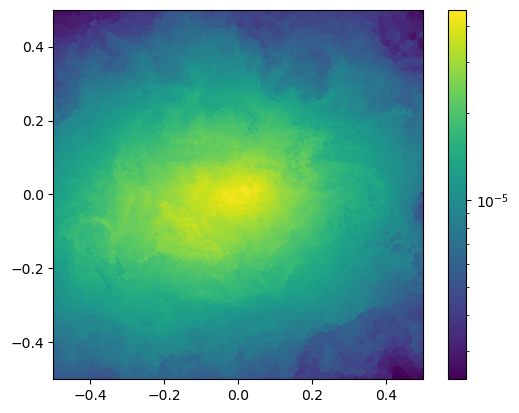

In [20]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize

widths_plot = widths
widths_plot[2] = 0.
slicer = pa.Slicer(snap, center, widths_plot, 'z', npix=512)
dens = slicer.slice_variable('0_Density')
plt.imshow(dens.value, origin='lower', norm=LogNorm(),extent=slicer.centered_extent.to('Mpc').value)
plt.colorbar()

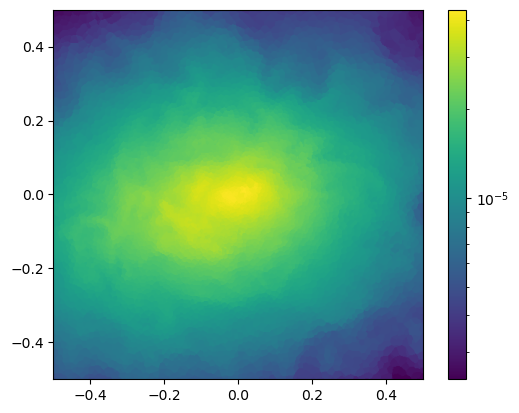

In [21]:

snap['0_smooth_var_default'] = snap['0_Density'].copy
snap['0_smooth_var_default'][sf.index] = filt_density

slicer = pa.Slicer(snap, center, widths_plot, 'z', npix=512)
dens_old = slicer.slice_variable('0_smooth_var_default')
plt.imshow(dens_old.value, origin='lower', norm=LogNorm(),extent=slicer.centered_extent.to('Mpc').value)
plt.colorbar()
# plt.savefig('cluster_gpu_ray_traced_wide.png', dpi=1400)

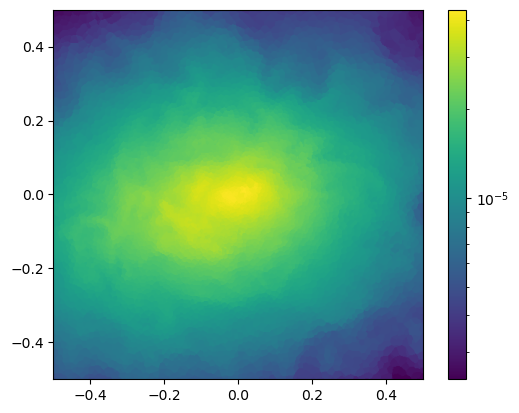

In [22]:

snap['0_smooth_var_sph'] = snap['0_Density'].copy
snap['0_smooth_var_sph'][sf_spherical.index] = filt_density_spherical

slicer = pa.Slicer(snap, center, widths_plot, 'z', npix=512)
dens_sph = slicer.slice_variable('0_smooth_var_sph')
plt.imshow(dens_sph.value, origin='lower', norm=LogNorm(),extent=slicer.centered_extent.to('Mpc').value)
plt.colorbar()
# plt.savefig('cluster_gpu_ray_traced_wide.png', dpi=1400)

In [23]:
dens_rel = np.abs(dens_old.value - dens_sph.value)/dens_old.value

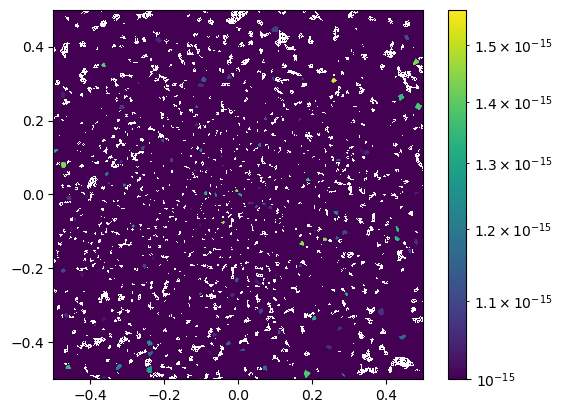

In [24]:
# from matplotlib.colors import LogNorm, Normalize

slicer = pa.Slicer(snap, center, widths_plot, 'z', npix=512)
plt.imshow(dens_rel, origin='lower', norm=LogNorm(vmin=1e-15),extent=slicer.centered_extent.to('Mpc').value)
plt.colorbar()

In [25]:
mask_spherical = np.zeros(snap['0_Density'].shape,dtype='int')
mask_spherical[sf_spherical.index] = sf_spherical.isParticleInDomainUnSorted.get()

In [26]:
np.sum(mask_spherical)

780485

In [27]:
mask_cartesian = np.zeros(snap['0_Density'].shape,dtype='int')
mask_cartesian[sf.index] = sf.isParticleInDomainUnSorted.get()

In [28]:
np.sum(mask_cartesian)

435429

In [29]:
mask_tot = mask_cartesian*mask_spherical

In [30]:
np.sum(mask_tot)

435429

In [31]:
np.allclose(snap['0_smooth_var_default'][np.argwhere(mask_tot>0)].value, 
            snap['0_smooth_var_sph'][np.argwhere(mask_tot>0)].value, 
            rtol=1e-12, atol=1e-8)

True

In [32]:
np.argwhere(np.abs(snap['0_smooth_var_default'][np.argwhere(mask_tot>0)].value-
            snap['0_smooth_var_sph'][np.argwhere(mask_tot>0)].value)/snap['0_smooth_var_default'][np.argwhere(mask_tot>0)].value>1e-2)

array([], shape=(0, 2), dtype=int64)

In [33]:
snap['0_smooth_var_default'][np.argwhere(mask_tot>0)][40102].value

array([2.26456319e-05])

In [34]:
np.argwhere(snap['0_smooth_var_default'].value==snap['0_smooth_var_default'][np.argwhere(mask_tot>0)][40102].value)

array([[40102]])

In [35]:
sf.index[42360]

True

In [36]:
sf.index[np.argwhere(mask_tot>0)][40102]

array([ True])

In [37]:
snap['0_Coordinates'][np.argwhere(mask_tot>0)][40102].value

array([[499674.33264337, 499697.60940848, 499743.28855181]])

In [38]:
snap['0_smooth_var_sph'][np.argwhere(mask_tot>0)][40102].value

array([2.26456319e-05])

In [39]:
sf.tile.unsort_index.shape

(5068012,)

In [40]:
sf.tile.sort_index.max()

array(5068011)

In [41]:
cp.sum(sf.index)

5068012

In [42]:
256**3

16777216

In [43]:
cp.sum(sf.tile.particles_per_tile)

array(5068012)

In [44]:
sf.Np

5068012

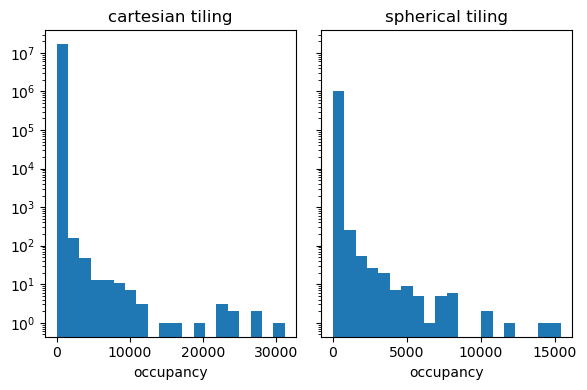

min/max occupancy cartesian tiling 0 / 31218
min/max occupancy spherical tiling 0 / 15406


In [45]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize

n_bins = 20

fig, axs = plt.subplots(1, 2, figsize=(6,4),sharey=True, tight_layout=True)

# We can set the number of bins with the *bins* keyword argument.
axs[0].hist(cp.asnumpy(sf.tile.particles_per_tile).flatten(), bins=n_bins)
axs[1].hist(cp.asnumpy(sf_spherical.tile.particles_per_tile).flatten(), bins=n_bins)

axs[0].set_yscale('log')
axs[1].set_yscale('log')

axs[0].set_title('cartesian tiling')
axs[1].set_title('spherical tiling')

axs[0].set_xlabel('occupancy')
axs[1].set_xlabel('occupancy')

plt.show()

print("min/max occupancy cartesian tiling %d / %d"%(sf.tile.particles_per_tile.min(),sf.tile.particles_per_tile.max()))
print("min/max occupancy spherical tiling %d / %d"%(sf_spherical.tile.particles_per_tile.min(),sf_spherical.tile.particles_per_tile.max()))

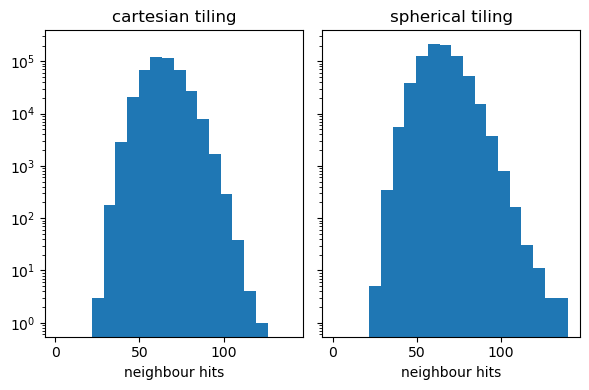

min/max hits cartesian tiling 0 / 121
min/max hits spherical tiling 0 / 139


In [46]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize

n_bins = 20

fig, axs = plt.subplots(1, 2, figsize=(6,4),sharey=True, tight_layout=True)

# We can set the number of bins with the *bins* keyword argument.
axs[0].hist(cp.asnumpy(sf.hitsNeighbours), bins=n_bins, range=[1,140])
axs[1].hist(cp.asnumpy(sf_spherical.hitsNeighbours), bins=n_bins,range=[1,140])

axs[0].set_yscale('log')
axs[1].set_yscale('log')

axs[0].set_title('cartesian tiling')
axs[1].set_title('spherical tiling')

axs[0].set_xlabel('neighbour hits')
axs[1].set_xlabel('neighbour hits')

plt.show()

print("min/max hits cartesian tiling %d / %d"%(sf.hitsNeighbours.min(),sf.hitsNeighbours.max()))
print("min/max hits spherical tiling %d / %d"%(sf_spherical.hitsNeighbours.min(),sf_spherical.hitsNeighbours.max()))

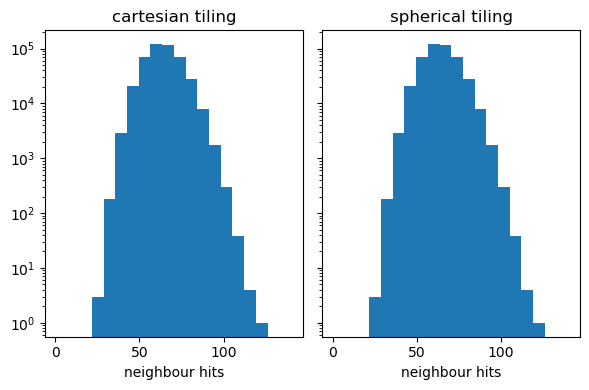

min/max hits cartesian tiling 27 / 121
min/max hits spherical tiling 27 / 121


In [47]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize

# this brings back the intersection region into the respective
# cartesian/spherical selection with appropriate sorting
masktot2spherical_srt = mask_tot[sf_spherical.index][sf_spherical.tile.sort_index.get()]
masktot2cartesian_srt = mask_tot[sf.index][sf.tile.sort_index.get()]

hitsNeighbours_cartesian_common = cp.asnumpy(sf.hitsNeighbours)[np.argwhere(masktot2cartesian_srt>0)]
hitsNeighbours_spherical_common = cp.asnumpy(sf_spherical.hitsNeighbours)[np.argwhere(masktot2spherical_srt>0)]

n_bins = 20

fig, axs = plt.subplots(1, 2, figsize=(6,4),sharey=True, tight_layout=True)

# We can set the number of bins with the *bins* keyword argument.
axs[0].hist(hitsNeighbours_cartesian_common, bins=n_bins, range=[1,140])
axs[1].hist(hitsNeighbours_spherical_common, bins=n_bins,range=[1,140])

axs[0].set_yscale('log')
axs[1].set_yscale('log')

axs[0].set_title('cartesian tiling')
axs[1].set_title('spherical tiling')

axs[0].set_xlabel('neighbour hits')
axs[1].set_xlabel('neighbour hits')

plt.show()

print("min/max hits cartesian tiling %d / %d"%(hitsNeighbours_cartesian_common.min(),hitsNeighbours_cartesian_common.max()))
print("min/max hits spherical tiling %d / %d"%(hitsNeighbours_spherical_common.min(),hitsNeighbours_spherical_common.max()))

In [48]:
sph_max_occupancy_cell = cp.argwhere(sf_spherical.tile.particles_per_tile==11298)[0]
print(sph_max_occupancy_cell)
idx_rad, idx_phi, idx_the = sph_max_occupancy_cell
print(sf_spherical.tile.start_index_for_tile[idx_rad, idx_phi, idx_the])

tileRMin = 10**(sf_spherical.tile.spacings[0]*idx_rad + math.log10(sf_spherical.tile._rMin))
print(tileRMin)
# sf_spherical.tile.particles_per_tile[idx_rad, idx_phi, idx_the]
# print('rel pos: ', sf_spherical.gpu_variables['pos'][weird_idx]-sf_spherical.gpu_variables['center'])

# print('filter length: ', sf_spherical.gpu_variables['filter_lengths'][weird_idx])

# print('hsml: ',sf_spherical.gpu_variables['hsml'][weird_idx])

IndexError: Index 0 is out of bounds for axis 0 with size 0

In [ ]:
sf_spherical.tile.spacings[0]*idx_rad + math.log10(sf_spherical.tile._rMin)

In [ ]:
(math.log10(6970.171077342815) - math.log10(sf_spherical.tile._rMin) ) // sf_spherical.tile.spacings[0]

In [ ]:
sf_spherical.tile._rMax

In [ ]:
filt_density_spherical[2519978+11298-1]

In [ ]:
weird_idx = cp.argwhere(sf.hitsNeighbours==51423)

print('rel pos: ', sf.gpu_variables['pos'][weird_idx]-sf.gpu_variables['center'])

print('filter length: ', sf.gpu_variables['filter_lengths'][weird_idx])

print('hsml: ',sf.gpu_variables['hsml'][weird_idx])

In [ ]:
snap['0_Masses'][int(sf.tile.sort_index[weird_idx])]

In [ ]:
snap['0_Volume'][int(sf.tile.sort_index[weird_idx])]

In [ ]:
snap['0_Masses'].min()

In [ ]:
snap['0_HighResGasMass'][int(sf.tile.sort_index[weird_idx])]/snap['0_Masses'][int(sf.tile.sort_index[weird_idx])]

In [ ]:
snap['0_Coordinates'][int(sf.tile.sort_index[weird_idx])]-center

In [ ]:
# # particle idx = 0 has null filt_density_spherical!
# # in which tile is it?
# ip_tile_R, ip_tile_phi, ip_tile_theta = sf_spherical.tile.tile_index[idx]
# xp, yp, zp = particlePos - sf_spherical.gpu_variables['center']
# rp = math.sqrt(xp*xp + yp*yp + zp*zp)
# phi = math.atan2(yp, xp) % (2.0*math.pi)
# theta = math.acos(zp/rp)
# hsml = sf_spherical.gpu_variables['hsml'][idx]
# fil = sf_spherical.gpu_variables['filter_lengths'][idx]
# rad2 = rp**2
# cylRadius = rp * math.sin(theta)
# filter_window = 4

# rp, phi, theta

# ip_tile_R, ip_tile_phi, ip_tile_theta

# if (sf_spherical.rMin.value > 2.0 * hsml):
#     rad2Min = (sf_spherical.rMin.value - 2.0 * hsml)**2
# else:
#     rad2Min = 0.0
# rad2Max = (sf_spherical.rMax.value + 2.0 * hsml)**2

# # Check if this cell/particle is inside domain
# inside_domain = False
# if (rad2 > rad2Min) and (rad2 < rad2Max):
#     inside_domain = True

# inside_domain

# if not (4 * fil < cylRadius):
#     print('not')

# nSectRad, nSectPhi, nSectThe = sf_spherical.tile.nSects
# nSectRad = int(nSectRad)
# nSectPhi = int(nSectPhi)
# nSectThe = int(nSectThe)
# radSpacing, phiSpacing, theSpacing = sf_spherical.tile.spacings
# _rMin = sf_spherical.tile._rMin
# ip_tile_phi_min = 0
# ip_tile_phi_max = nSectPhi - 1
# # regarding latitudinal range, three cases:
# # case 1. particle+search radius is entirely in z>0 midplane
# # case 2. particle+search radius is entirely in z<0 midplane
# # case 3. particle+search radius overlaps with origin 
# # for case 3. the latitudinal tiles go from 0 to nSectThe -1
# ip_tile_the_min = 0
# ip_tile_the_max = nSectThe - 1
# if (zp > filter_window * fil):
#     # case 1. search latitudinal tiles from 0 to ip_tile_the_max
#     delta_theta = math.asin((filter_window * fil) / rp)
#     ip_tile_the_max = int((theta + delta_theta) // sf_spherical.tile.theSpacing)
# elif (- zp > filter_window * fil):
#     delta_theta = math.asin((filter_window * fil) / rp)
#     ip_tile_the_min = int((theta - delta_theta) // sf_spherical.tile.theSpacing)

# delta_rad = filter_window * fil
# ip_tile_rad_min = 0
# if (rp - delta_rad > _rMin):
#     ip_tile_rad_min = int((math.log10(rp - delta_rad) - \
#                        math.log10(_rMin) ) // radSpacing)
# ip_tile_rad_max = int((math.log10(rp + delta_rad) - \
#                    math.log10(_rMin) ) // radSpacing)

# weight = 0.0
# weight_tmp = 0.0
# smooth_var = 0.0
# hitsNeighbours = 0.0
# for tile_rad in range(ip_tile_rad_min, ip_tile_rad_max + 1):
#     for tile_phi in range(ip_tile_phi_min, ip_tile_phi_max + 1):
#         for tile_the in range(ip_tile_the_min, ip_tile_the_max + 1):

#             start_index = int(sf_spherical.tile.start_index_for_tile[tile_rad,
#                                                tile_phi, tile_the])
#             n_particles = int(sf_spherical.tile.particles_per_tile[tile_rad,
#                                                tile_phi, tile_the])

#             for ip_other in range(start_index, start_index + n_particles):
#                 dist = distance_cpu(sf_spherical.gpu_variables['pos'][idx], sf_spherical.gpu_variables['pos'][ip_other])
#                 if dist < filter_window * fil:
#                     weight_tmp = gaussian_kernel_cpu(dist, fil) * sf_spherical.gpu_variables['0_Volume'][ip_other]
#                     weight += weight_tmp
#                     smooth_var += sf_spherical.gpu_variables['0_Density'][ip_other] * weight_tmp
#                     hitsNeighbours += 1

# ip_tile_rad_min, ip_tile_rad_max, ip_tile_phi_min, ip_tile_phi_max, ip_tile_the_min, ip_tile_the_max

In [ ]:
# # check that the tiling was done correctly for this particle
# ip_tile_rad = 0
# if (rp > sf_spherical.tile._rMin):
#     ip_tile_rad = math.log10(rp) - math.log10(sf_spherical.tile._rMin) // sf_spherical.tile.radSpacing
# ip_tile_phi = int((phi - 0.0) // sf_spherical.tile.phiSpacing)
# ip_tile_the = int((theta - 0.0) // sf_spherical.tile.theSpacing)
# assert ([ip_tile_rad,ip_tile_phi,ip_tile_the] == sf_spherical.tile.tile_index[0].get()).all()

# # are there other particles in the same tile?
# num_part_per_tile = sf_spherical.tile.particles_per_tile[ip_tile_rad,ip_tile_phi,ip_tile_the]
# # what is the starting index for this tile?
# start_idx_for_tile = sf_spherical.tile.start_index_for_tile[ip_tile_rad,ip_tile_phi,ip_tile_the]
# # what is the filter length for this particle?
# filt_lengthParticle = sf_spherical.gpu_variables['filter_lengths'][0]